In [26]:
# Import libraries
import pandas as pd
import numpy as np

In [30]:
# Load dataset
df = pd.read_csv('Fraud .csv')
df.head(5)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [32]:
print(df.shape)


(51000, 12)


In [34]:
print(df.isnull().sum())


Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64


In [36]:
print(df.duplicated().sum())

881


In [38]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)
print(df.shape)

(50119, 12)


In [40]:
# Drop rows with missing values
df.dropna(inplace=True)
print(df.shape)

(38895, 12)


In [42]:
# Drop irrelevant columns
df.drop(columns=['Transaction_ID', 'User_ID'], inplace=True)
print(df.head(5))

   Transaction_Amount Transaction_Type  Time_of_Transaction Device_Used  \
0             1292.76   ATM Withdrawal                 16.0      Tablet   
1             1554.58   ATM Withdrawal                 13.0      Mobile   
3              100.10     Bill Payment                 15.0     Desktop   
4             1490.50      POS Payment                 19.0      Mobile   
5             2372.04   ATM Withdrawal                 15.0     Desktop   

        Location  Previous_Fraudulent_Transactions  Account_Age  \
0  San Francisco                                 0          119   
1       New York                                 4           79   
3        Chicago                                 4            3   
4  San Francisco                                 2           57   
5         Boston                                 3           96   

   Number_of_Transactions_Last_24H Payment_Method  Fraudulent  
0                               13     Debit Card           0  
1                 

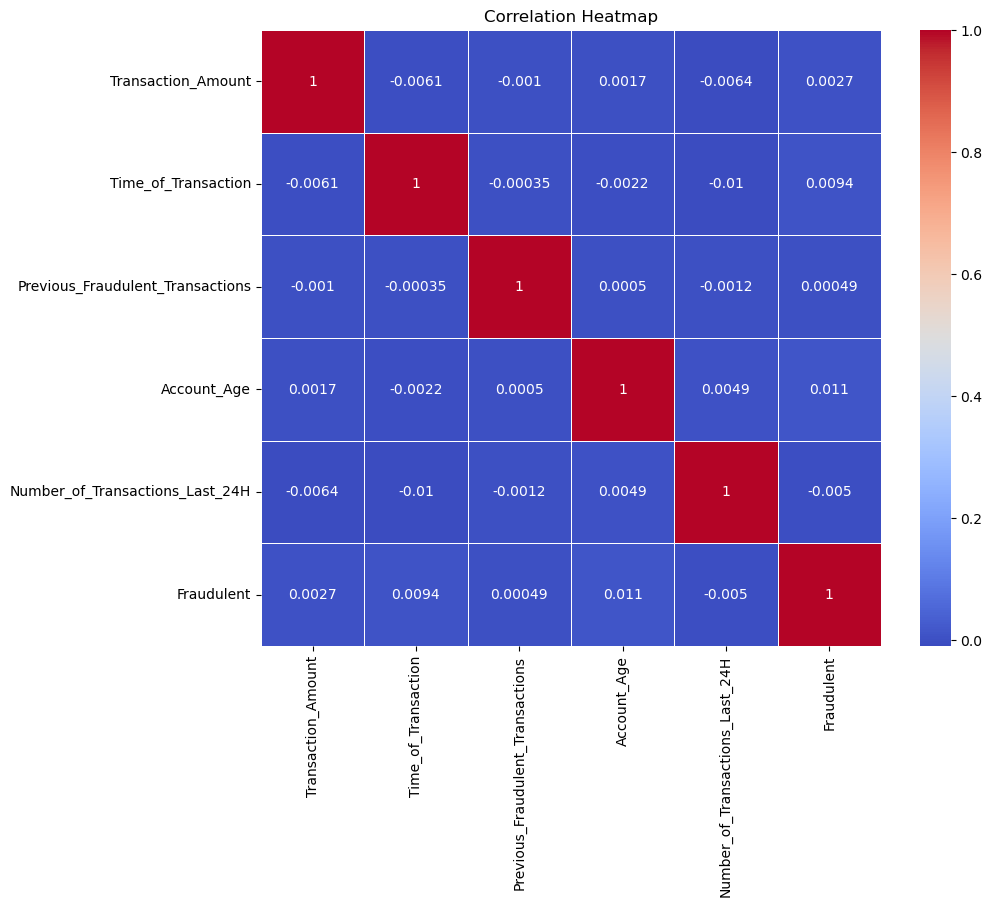

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidth=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [46]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Transaction_Type'] = le.fit_transform(df['Transaction_Type'])
df['Device_Used'] = le.fit_transform(df['Device_Used'])
df['Location'] = le.fit_transform(df['Location'])
df['Payment_Method'] = le.fit_transform(df['Payment_Method'])
print(df.head(5))

   Transaction_Amount  Transaction_Type  Time_of_Transaction  Device_Used  \
0             1292.76                 0                 16.0            2   
1             1554.58                 0                 13.0            1   
3              100.10                 2                 15.0            0   
4             1490.50                 4                 19.0            1   
5             2372.04                 0                 15.0            0   

   Location  Previous_Fraudulent_Transactions  Account_Age  \
0         6                                 0          119   
1         5                                 4           79   
3         1                                 4            3   
4         6                                 2           57   
5         0                                 3           96   

   Number_of_Transactions_Last_24H  Payment_Method  Fraudulent  
0                               13               1           0  
1                                3

In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Transaction_Amount', 'Time_of_Transaction', 'Account_Age', 'Number_of_Transactions_Last_24H']] = scaler.fit_transform(
    df[['Transaction_Amount', 'Time_of_Transaction', 'Account_Age', 'Number_of_Transactions_Last_24H']]
)
print(df.head(5))

   Transaction_Amount  Transaction_Type  Time_of_Transaction  Device_Used  \
0           -0.336692                 0             0.656763            2   
1           -0.284980                 0             0.222758            1   
3           -0.572255                 2             0.512095            0   
4           -0.297636                 4             1.090768            1   
5           -0.123523                 0             0.512095            0   

   Location  Previous_Fraudulent_Transactions  Account_Age  \
0         6                                 0     1.720628   
1         5                                 4     0.555437   
3         1                                 4    -1.658428   
4         6                                 2    -0.085419   
5         0                                 3     1.050643   

   Number_of_Transactions_Last_24H  Payment_Method  Fraudulent  
0                         1.369829               1           0  
1                        -1.118984

In [50]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Fraudulent'])
y = df['Fraudulent']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Classification Report: ", classification_report(y_test, y_pred))

Accuracy:  0.952436045764237
Classification Report:                precision    recall  f1-score   support

           0       0.95      1.00      0.98      7409
           1       0.00      0.00      0.00       370

    accuracy                           0.95      7779
   macro avg       0.48      0.50      0.49      7779
weighted avg       0.91      0.95      0.93      7779



C:\Users\alka2\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\alka2\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\alka2\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [54]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred_dt))
print("classification Report: ", classification_report(y_test, y_pred_dt))

Accuracy:  0.9523074945365728
classification Report:                precision    recall  f1-score   support

           0       0.95      1.00      0.98      7409
           1       0.00      0.00      0.00       370

    accuracy                           0.95      7779
   macro avg       0.48      0.50      0.49      7779
weighted avg       0.91      0.95      0.93      7779

